# Module 2 — Risk Scoring
## Goal: Score every customer with churn probability and assign risk label
## Output: risk_scored_customers.csv — this feeds directly into Power BI

In [3]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load ML ready data
df_ml = pd.read_csv('../data/telco_churn_ml_ready.csv')

# Load CLV scores
df_clv = pd.read_csv('../outputs/clv_scores.csv')

# Load trained model
with open('../outputs/xgb_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

# Load feature names
with open('../outputs/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

print(f"ML data: {df_ml.shape}")
print(f"CLV data: {df_clv.shape}")
print("Model and features loaded successfully")

ML data: (7032, 28)
CLV data: (7032, 9)
Model and features loaded successfully


Generate Churn Probabilities

In [4]:
# Prepare features
X = df_ml[feature_names]

# Predict churn probability for every customer
churn_proba = xgb_model.predict_proba(X)[:, 1]

print(f"Churn probabilities generated for {len(churn_proba)} customers")
print(f"\nProbability distribution:")
print(pd.Series(churn_proba).describe().round(3))

Churn probabilities generated for 7032 customers

Probability distribution:
count    7032.000
mean        0.399
std         0.311
min         0.003
25%         0.082
50%         0.347
75%         0.694
max         0.971
dtype: float64


In [ ]:
def assign_risk(prob):
    if prob >= 0.7:
        return 'High Risk'
    elif prob >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

risk_labels = pd.Series(churn_proba).apply(assign_risk)

print("Risk Label Distribution:")
print(risk_labels.value_counts())
print("\nRisk Label %:")
print((risk_labels.value_counts(normalize=True) * 100).round(2))

Risk Label Distribution:
Low Risk       3765
High Risk      1731
Medium Risk    1536
Name: count, dtype: int64

Risk Label %:
Low Risk       53.54
High Risk      24.62
Medium Risk    21.84
Name: proportion, dtype: float64


Risk Scored Dataset

In [4]:
risk_df = pd.DataFrame({
    'customerID': df_ml['customerID'],
    'Churn_Probability': churn_proba.round(4),
    'Risk_Label': risk_labels
})

# Merge with CLV scores
risk_df = risk_df.merge(
    df_clv[['customerID','tenure','MonthlyCharges','TotalCharges',
            'Segment','CLV_Enhanced','CLV_Tier','Churn']],
    on='customerID',
    how='left'
)

print(f"Risk scored dataset shape: {risk_df.shape}")
risk_df.head(10)

Risk scored dataset shape: (7032, 10)


,customerID,Churn_Probability,Risk_Label,tenure,MonthlyCharges,TotalCharges,Segment,CLV_Enhanced,CLV_Tier,Churn
0,7590-VHVEG,0.8734,High Risk,1,29.85,29.85,Inactive,7.46,Low Value,No
1,5575-GNVDE,0.0838,Low Risk,34,56.95,1889.50,At Risk,1102.21,High Value,No
2,3668-QPYBK,0.6258,Medium Risk,2,53.85,108.15,Inactive,45.06,Low Value,Yes
3,7795-CFOCW,0.0674,Low Risk,45,42.30,1840.75,At Risk,1073.77,High Value,No
4,9237-HQITU,0.8359,High Risk,2,70.70,151.65,Inactive,63.19,Low Value,Yes
5,9305-CDSKC,0.9515,High Risk,8,99.65,820.50,Loyal Customers,547.00,Medium Value,Yes
6,1452-KIOVK,0.6591,Medium Risk,22,89.10,1949.40,Loyal Customers,1299.60,High Value,No
7,6713-OKOMC,0.5264,Medium Risk,10,29.75,301.90,Inactive,100.63,Low Value,No
8,7892-POOKP,0.8153,High Risk,28,104.80,3046.05,Champions,2538.38,High Value,Yes
9,6388-TABGU,0.0296,Low Risk,62,56.15,3487.95,Loyal Customers,2325.30,High Value,No


Assign Priority Level

In [5]:
# Priority = combination of Risk Label + CLV Tier
# This is the core of Module 3 retention strategy

def assign_priority(row):
    risk = row['Risk_Label']
    clv = row['CLV_Tier']
    
    if risk == 'High Risk' and clv in ['Premium', 'High Value']:
        return 'Critical'
    elif risk == 'High Risk' and clv in ['Medium Value', 'Low Value']:
        return 'High'
    elif risk == 'Medium Risk' and clv in ['Premium', 'High Value']:
        return 'High'
    elif risk == 'Medium Risk':
        return 'Medium'
    else:
        return 'Low'

risk_df['Priority'] = risk_df.apply(assign_priority, axis=1)

print("Priority Distribution:")
print(risk_df['Priority'].value_counts())

Priority Distribution:
Priority
Low         3765
High        2127
Medium       677
Critical     463
Name: count, dtype: int64


Assign Retention Strategy

In [6]:
def assign_retention(row):
    risk = row['Risk_Label']
    clv = row['CLV_Tier']
    
    if risk == 'High Risk' and clv in ['Premium', 'High Value']:
        return 'Personal Relationship Manager'
    elif risk == 'High Risk' and clv == 'Medium Value':
        return 'Discount Offer'
    elif risk == 'High Risk' and clv == 'Low Value':
        return 'Email Campaign'
    elif risk == 'Medium Risk' and clv in ['Premium', 'High Value']:
        return 'Loyalty Reward'
    elif risk == 'Medium Risk':
        return 'SMS Reminder'
    else:
        return 'No Action Needed'

risk_df['Retention_Strategy'] = risk_df.apply(assign_retention, axis=1)

print("Retention Strategy Distribution:")
print(risk_df['Retention_Strategy'].value_counts())

Retention Strategy Distribution:
Retention_Strategy
No Action Needed                 3765
Loyalty Reward                    859
Email Campaign                    776
SMS Reminder                      677
Discount Offer                    492
Personal Relationship Manager     463
Name: count, dtype: int64


Risk Distribution

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5792\2527173363.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=priority_counts.index, y=priority_counts.values,


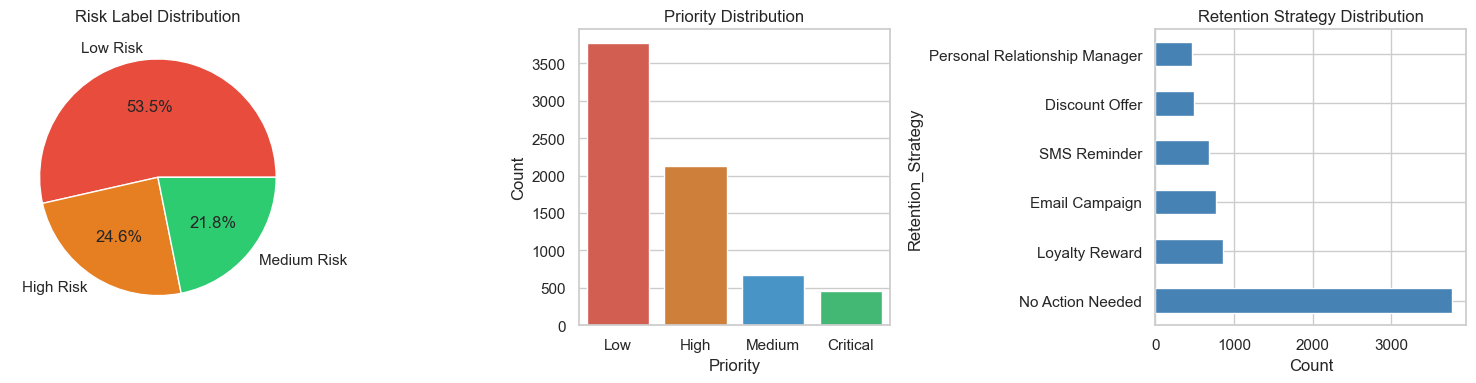

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Risk Label
risk_counts = risk_df['Risk_Label'].value_counts()
axes[0].pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%',
            colors=['#e74c3c','#e67e22','#2ecc71'])
axes[0].set_title('Risk Label Distribution')

# Priority
priority_counts = risk_df['Priority'].value_counts()
sns.barplot(x=priority_counts.index, y=priority_counts.values,
            palette=['#e74c3c','#e67e22','#3498db','#2ecc71'],
            ax=axes[1])
axes[1].set_title('Priority Distribution')
axes[1].set_xlabel('Priority')
axes[1].set_ylabel('Count')

# Retention Strategy
strategy_counts = risk_df['Retention_Strategy'].value_counts()
strategy_counts.plot(kind='barh', color='steelblue', ax=axes[2])
axes[2].set_title('Retention Strategy Distribution')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

Churn Probability by Segment

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5792\475558667.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=risk_df, x='Segment', y='Churn_Probability',


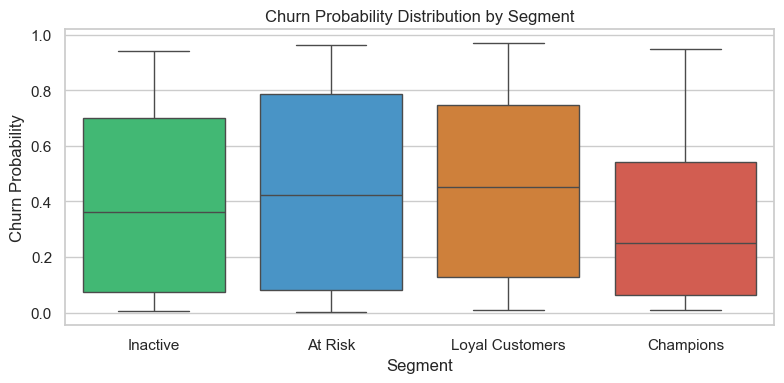

In [8]:
plt.figure(figsize=(8,4))
sns.boxplot(data=risk_df, x='Segment', y='Churn_Probability',
            palette=['#2ecc71','#3498db','#e67e22','#e74c3c'])
plt.title('Churn Probability Distribution by Segment')
plt.xlabel('Segment')
plt.ylabel('Churn Probability')
plt.tight_layout()
plt.show()

In [9]:
risk_df.to_csv('../outputs/risk_scored_customers.csv', index=False)

print("Risk scored customers saved to ../outputs/risk_scored_customers.csv")
print(f"Final shape: {risk_df.shape}")
print(f"\nColumns in output:")
print(risk_df.columns.tolist())
risk_df.head()

Risk scored customers saved to ../outputs/risk_scored_customers.csv
Final shape: (7032, 12)

Columns in output:
['customerID', 'Churn_Probability', 'Risk_Label', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Segment', 'CLV_Enhanced', 'CLV_Tier', 'Churn', 'Priority', 'Retention_Strategy']


,customerID,Churn_Probability,Risk_Label,tenure,MonthlyCharges,TotalCharges,Segment,CLV_Enhanced,CLV_Tier,Churn,Priority,Retention_Strategy
0,7590-VHVEG,0.8734,High Risk,1,29.85,29.85,Inactive,7.46,Low Value,No,High,Email Campaign
1,5575-GNVDE,0.0838,Low Risk,34,56.95,1889.50,At Risk,1102.21,High Value,No,Low,No Action Needed
2,3668-QPYBK,0.6258,Medium Risk,2,53.85,108.15,Inactive,45.06,Low Value,Yes,Medium,SMS Reminder
3,7795-CFOCW,0.0674,Low Risk,45,42.30,1840.75,At Risk,1073.77,High Value,No,Low,No Action Needed
4,9237-HQITU,0.8359,High Risk,2,70.70,151.65,Inactive,63.19,Low Value,Yes,High,Email Campaign


## Risk Scoring Summary

| Risk Label | Threshold | Business Meaning |
|---|---|---|
| High Risk | Probability >= 0.70 | Immediate action required |
| Medium Risk | Probability >= 0.40 | Monitor and engage |
| Low Risk | Probability < 0.40 | No action needed |

| Priority | Definition | Retention Action |
|---|---|---|
| Critical | High Risk + Premium/High CLV | Personal Relationship Manager |
| High | High Risk + Low CLV or Medium Risk + High CLV | Discount Offer / Loyalty Reward |
| Medium | Medium Risk + Medium CLV | SMS Reminder |
| Low | Low Risk | No Action Needed |

**Output file: risk_scored_customers.csv — feeds directly into Power BI dashboard**